# Prompt-optimization gains by student / teacher / judge

Pools every training run from an MLflow experiment, groups them by the
**(student, teacher, judge)** model triple (and prompt-optimization technique),
and reports the quality **gain** (`test_quality_after - test_quality_before`)
aggregated over the available `sampler_seed`s as **mean ± std**.

Finally it prints the **optimized (final) prompt** registered by each run.

Run mapping (see `src/experiments/text2sql/train_*.py`):

| role | param |
|------|-------|
| student | `model` |
| teacher | `teacher_model` (GEPA) / `optimizer_model` (TextGrad, SkillOpt) |
| judge | `judge_model` |
| seed | `sampler_seed` |
| gain | `test_quality_after - test_quality_before` |


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# Load tracking URI + MinIO/S3 artifact credentials so prompt templates are readable.
load_dotenv(Path.cwd().parent / ".env")

# Which experiment to pool. Override by setting MLFLOW_EXPERIMENT in the environment.
EXPERIMENT = os.environ.get(
    "MLFLOW_EXPERIMENT",
    os.environ.get("MLFLOW_TRAIN_EXPERIMENT_NAME", "train-text2sql"),
)
mlflow.set_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000"))
client = mlflow.MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment:   {EXPERIMENT}")

/home/al/projects/Evaluating-prompt-optimization-techniques-for-water-management-LLM-assistant-with-RAG/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tracking URI: http://localhost:5000
Experiment:   train-text2sql


## 1. Pool runs from the experiment

`mlflow.genai.optimize_prompts` spawns nested child runs that carry no `technique`
param, so we keep only the top-level technique runs.

In [2]:
raw = mlflow.search_runs(experiment_names=[EXPERIMENT], max_results=5000)


def col(df, name, default=np.nan):
    """Return a param/metric column or a constant fallback if it was never logged."""
    return df[name] if name in df.columns else pd.Series(default, index=df.index)


tech = raw[col(raw, "params.technique").notna()].copy()

# Teacher role is named differently per technique -> coalesce into one column.
teacher = col(tech, "params.teacher_model").fillna(col(tech, "params.optimizer_model"))

runs = pd.DataFrame(
    {
        "run_id": tech["run_id"],
        "technique": col(tech, "params.technique"),
        "student": col(tech, "params.model"),
        "teacher": teacher,
        "judge": col(tech, "params.judge_model"),
        "seed": pd.to_numeric(col(tech, "params.sampler_seed"), errors="coerce").astype("Int64"),
        "quality_before": pd.to_numeric(col(tech, "metrics.test_quality_before"), errors="coerce"),
        "quality_after": pd.to_numeric(col(tech, "metrics.test_quality_after"), errors="coerce"),
    }
).reset_index(drop=True)
runs["gain"] = runs["quality_after"] - runs["quality_before"]

n_failed = runs["gain"].isna().sum()
if n_failed:
    print(f"Dropping {n_failed} run(s) with missing before/after metric (failed/incomplete).")
runs = runs.dropna(subset=["gain"]).reset_index(drop=True)

print(f"{len(runs)} usable technique runs.")
runs

Dropping 1 run(s) with missing before/after metric (failed/incomplete).
10 usable technique runs.


,run_id,technique,student,teacher,judge,seed,quality_before,quality_after,gain
0,5e32c312ecaf49a284cd963978606cfe,textgrad,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,41,0.56,0.52,-0.04
1,79448c0dc37a492d9ce543f21dba8580,skillopt,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,43,0.48,0.68,0.20
2,368fa98dd6a54e4faff682ac256a8b88,skillopt,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,42,0.64,0.76,0.12
3,2dec2e47fe9542e6b921f73ebe43c851,skillopt,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,41,0.40,0.76,0.36
4,e5920c3e68724a85964381ee117edcd3,gepa,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,43,0.48,0.68,0.20
5,28e3f15bfad04c2c9e7609a62c85ca05,gepa,openai/alias-qwen36-35b,openai/alias-qwen36-35b,openai/alias-qwen36-35b,43,0.40,0.68,0.28
6,51dcc72b3da149f2a9b37778cbe40d8e,gepa,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,42,0.48,0.72,0.24
7,b2ab55224de84de2b7669ae69aa22e32,gepa,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,41,0.40,0.64,0.24
8,911263cc351f4cd68ee50b6f36f059b2,gepa,openai/alias-qwen36-35b,openai/qwen3.5-397b-a17b,openai/qwen3.5-122b-a10b,42,0.48,0.60,0.12
9,e4cfbf94efee447f93be9ae21320b89c,gepa,openai/alias-qwen36-35b,openai/qwen3.5-397b-a17b,openai/qwen3.5-397b-a17b,42,0.60,0.56,-0.04


## 2. Group by (student, teacher, judge) × technique — mean ± std over seeds

In [3]:
GROUP_KEYS = ["student", "teacher", "judge", "technique"]

agg = (
    runs.groupby(GROUP_KEYS, dropna=False)
    .agg(
        n_seeds=("seed", "nunique"),
        seeds=("seed", lambda s: sorted(int(x) for x in s.dropna().unique())),
        gain_mean=("gain", "mean"),
        gain_std=("gain", "std"),
        before_mean=("quality_before", "mean"),
        after_mean=("quality_after", "mean"),
    )
    .reset_index()
    .sort_values(["student", "teacher", "judge", "gain_mean"], ascending=[True, True, True, False])
    .reset_index(drop=True)
)
# std is NaN for single-seed groups; show 0 for those (no spread observed yet).
agg["gain_std"] = agg["gain_std"].fillna(0.0)
agg

,student,teacher,judge,technique,n_seeds,seeds,gain_mean,gain_std,before_mean,after_mean
0,openai/alias-qwen36-35b,openai/alias-qwen36-35b,openai/alias-qwen36-35b,gepa,1,[43],0.280000,0.000000,0.400000,0.680000
1,openai/alias-qwen36-35b,openai/qwen3.5-397b-a17b,openai/qwen3.5-122b-a10b,gepa,1,[42],0.120000,0.000000,0.480000,0.600000
2,openai/alias-qwen36-35b,openai/qwen3.5-397b-a17b,openai/qwen3.5-397b-a17b,gepa,1,[42],-0.040000,0.000000,0.600000,0.560000
3,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,gepa,3,"[41, 42, 43]",0.226667,0.023094,0.453333,0.680000
4,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,skillopt,3,"[41, 42, 43]",0.226667,0.122202,0.506667,0.733333
5,openai/alias-qwen36-35b,openai/qwen3.6-35b-a3b,openai/qwen3.6-35b-a3b,textgrad,1,[41],-0.040000,0.000000,0.560000,0.520000


## 3. Plot gains (mean ± std over seeds)

One bar per (student, teacher, judge) triple, colored by technique; error bars are
the std of the gain across seeds.

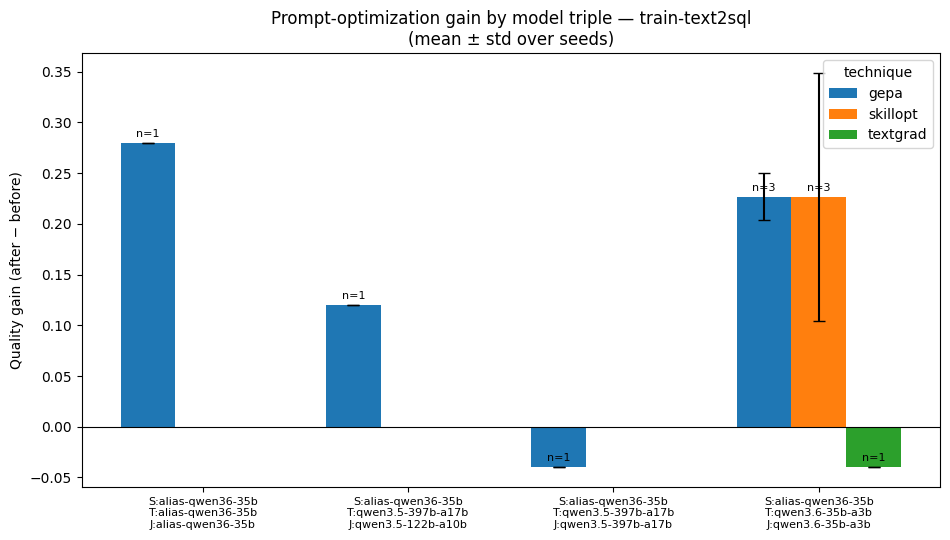

In [4]:
def short(model):
    """Strip the litellm provider prefix for compact axis labels."""
    return str(model).split("/")[-1]


agg["triple"] = agg.apply(
    lambda r: f"S:{short(r.student)}\nT:{short(r.teacher)}\nJ:{short(r.judge)}", axis=1
)
triples = list(dict.fromkeys(agg["triple"]))
techniques = sorted(agg["technique"].unique())

x = np.arange(len(triples))
width = 0.8 / max(len(techniques), 1)
fig, ax = plt.subplots(figsize=(max(8, 2.4 * len(triples)), 5.5))

for i, t in enumerate(techniques):
    sub = agg[agg["technique"] == t].set_index("triple")
    means = [sub["gain_mean"].get(tr, np.nan) for tr in triples]
    stds = [sub["gain_std"].get(tr, np.nan) for tr in triples]
    bars = ax.bar(x + i * width, means, width, yerr=stds, capsize=4, label=t)
    for tr, b in zip(triples, bars):
        n = sub["n_seeds"].get(tr)
        if pd.notna(b.get_height()) and pd.notna(n):
            ax.annotate(
                f"n={int(n)}",
                (b.get_x() + b.get_width() / 2, b.get_height()),
                textcoords="offset points", xytext=(0, 3),
                ha="center", va="bottom", fontsize=8,
            )

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x + width * (len(techniques) - 1) / 2)
ax.set_xticklabels(triples, fontsize=8)
ax.set_ylabel("Quality gain (after − before)")
ax.set_title(f"Prompt-optimization gain by model triple — {EXPERIMENT}\n(mean ± std over seeds)")
ax.legend(title="technique")
fig.tight_layout()

figdir = Path("figures")
figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "prompt_opt_gains.png", dpi=150, bbox_inches="tight")
plt.show()

### Before vs. after quality (mean over seeds)

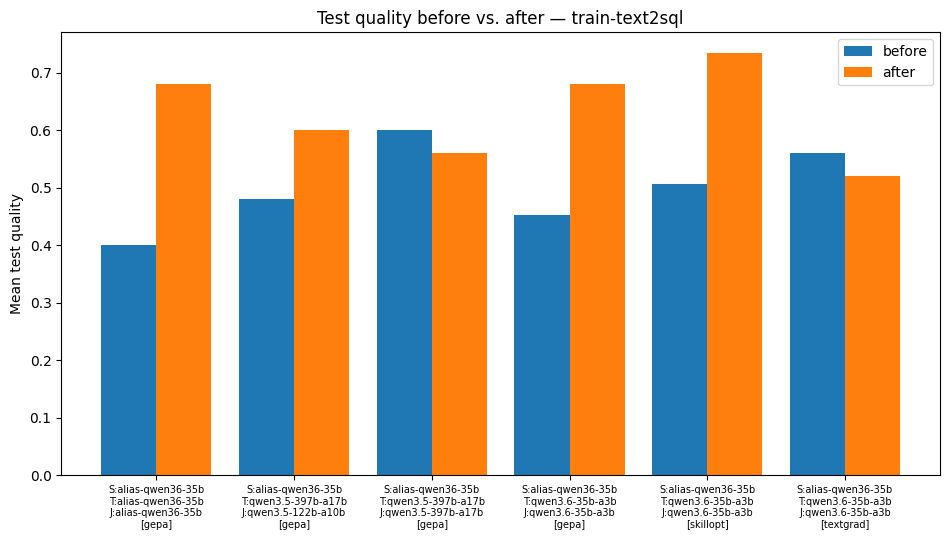

In [5]:
fig, ax = plt.subplots(figsize=(max(8, 2.4 * len(triples)), 5.5))
labels = agg["triple"] + "\n[" + agg["technique"] + "]"
xx = np.arange(len(agg))
ax.bar(xx - 0.2, agg["before_mean"], 0.4, label="before")
ax.bar(xx + 0.2, agg["after_mean"], 0.4, label="after")
ax.set_xticks(xx)
ax.set_xticklabels(labels, fontsize=7, rotation=0)
ax.set_ylabel("Mean test quality")
ax.set_title(f"Test quality before vs. after — {EXPERIMENT}")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Final (optimized) prompts per run

Each run links its prompt versions via the `mlflow.linkedPrompts` tag: the seed
version plus the optimized version registered by the optimizer. The optimized
template is the highest linked `text2sql_system` version (falls back to the seed
when optimization did not improve and no new version was registered).

In [6]:
import json

PROMPT_NAME = "text2sql_system"
_template_cache: dict[int, str] = {}


def load_template(version: int) -> str:
    if version not in _template_cache:
        _template_cache[version] = client.get_prompt_version(PROMPT_NAME, version).template
    return _template_cache[version]


def final_prompt(run_id: str) -> str:
    """Return the optimized text2sql_system template linked to a run."""
    tag = client.get_run(run_id).data.tags.get("mlflow.linkedPrompts")
    if not tag:
        return "<no linked prompts on this run>"
    versions = [
        int(p["version"]) for p in json.loads(tag) if p.get("name") == PROMPT_NAME
    ]
    if not versions:
        return "<no text2sql_system prompt linked>"
    return load_template(max(versions))

In [7]:
ordered = runs.sort_values(["student", "teacher", "judge", "technique", "seed"])
for _, r in ordered.iterrows():
    print("=" * 100)
    print(
        f"technique={r.technique}  seed={r.seed}  gain={r.gain:+.3f}  "
        f"({r.quality_before:.2f} -> {r.quality_after:.2f})"
    )
    print(f"student={r.student}  teacher={r.teacher}  judge={r.judge}")
    print(f"run_id={r.run_id}")
    print("-" * 100)
    print(final_prompt(r.run_id))
    print()

technique=gepa  seed=43  gain=+0.280  (0.40 -> 0.68)
student=openai/alias-qwen36-35b  teacher=openai/alias-qwen36-35b  judge=openai/alias-qwen36-35b
run_id=28e3f15bfad04c2c9e7609a62c85ca05
----------------------------------------------------------------------------------------------------
You are an expert DuckDB SQL author. Given a natural-language question and a database schema, produce ONE DuckDB-dialect SQL query that answers the question.

Strict output rules:
- Return ONLY the SQL query. No prose. No explanation. No markdown code fences.
- Use DuckDB SQL syntax (e.g. DATE_TRUNC, INTERVAL, NULLIF, CORR, UNION ALL, EPOCH).
- Use only the tables and columns provided in the schema. Do not invent identifiers.
- Reference tables by the exact name from the schema.
- If the question cannot be answered with the given schema, return a single line: -- unanswerable

Critical query construction guidelines:
1. Temporal Aggregation & Averaging: Carefully parse temporal phrasing. If the question

You are an expert DuckDB SQL author. Given a natural-language question and a database schema, produce ONE DuckDB-dialect SQL query that answers the question.

Strict output rules:
- Return ONLY the SQL query. No prose. No explanation. No markdown code fences.
- Use DuckDB SQL syntax (e.g. DATE_TRUNC, INTERVAL, list/struct functions, EPOCH, QUALIFY, UNPIVOT, CTEs).
- Use only the tables and columns provided in the schema. Do not invent identifiers.
- Reference tables by the exact name from the schema.
- If the question cannot be answered with the given schema, return a single line: -- unanswerable

Critical temporal, aggregation & join guidelines:
- The schema timestamps are typically sub-daily (e.g., hourly). NEVER join or filter on exact `timestamp` values when the question implies daily, monthly, or period-based conditions. Always aggregate or group by day using `DATE_TRUNC('day', timestamp)` or `CAST(timestamp AS DATE)`. Use `DATE_TRUNC('month', timestamp)` for monthly aggregations.

## 5. Initial benchmark by sampler seed (matched-seed comparison)

Focuses on the **before** metrics — `initial_eval_score` (val baseline) and
`test_quality_before` (test baseline) — pivoted by **sampler seed × technique**.

These baselines depend only on `(seed, seed-prompt, task model)`, **not** on the
optimization technique: the optimizer hasn't run yet when they're measured, and the seed
prompt text is byte-identical across every run (sha `42b149b6…`). So at a fixed seed all
three techniques *should* report the same baseline, up to eval non-determinism (the task
model is sampled at `temperature=0.05` on a 25-row split, and the endpoint doesn't pin
`seed`/`top_k`, giving a ±~12 pt swing — observed directly in the seed-42 GEPA runs:
0.48 / 0.36 / 0.48 on identical inputs).

Read the bars **within each seed**: a genuine technique effect would mean one technique is
consistently on top *across* seeds. It isn't — the ordering flips seed to seed, and
TextGrad has an `init_eval` at only one seed (41), so it can't be ranked against the
others on the val baseline at all.


=== init_eval by seed x technique (judge=openai/qwen3.6-35b-a3b) ===
seed         41    42    43
technique                  
gepa       0.48  0.48  0.48
skillopt   0.56  0.44  0.56
textgrad   0.60   -     -  

=== test_before by seed x technique (judge=openai/qwen3.6-35b-a3b) ===
seed         41    42    43
technique                  
gepa       0.40  0.48  0.48
skillopt   0.40  0.64  0.48
textgrad   0.56  0.56   -  



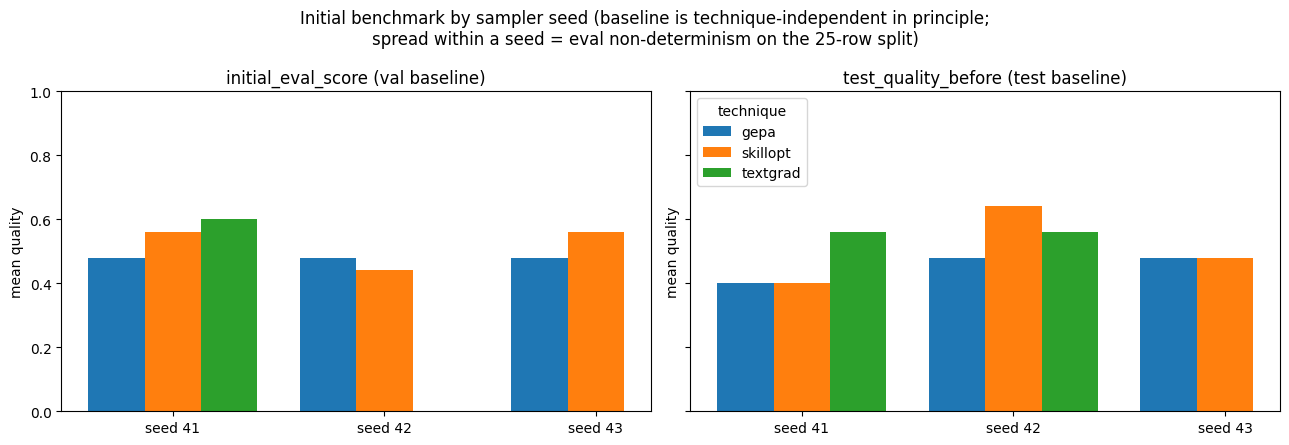

In [8]:
# Initial-benchmark frame: the BEFORE metrics, which depend only on (seed, seed-prompt,
# task model) and NOT on the technique -- so at a fixed seed all techniques should agree
# up to eval non-determinism. `initial_eval_score` is the baseline val score; the seed
# prompt text is byte-identical across all runs (verified: sha 42b149b6...).
bench = pd.DataFrame(
    {
        "technique": col(tech, "params.technique"),
        "judge": col(tech, "params.judge_model"),
        "seed": pd.to_numeric(col(tech, "params.sampler_seed"), errors="coerce").astype("Int64"),
        "init_eval": pd.to_numeric(col(tech, "metrics.initial_eval_score"), errors="coerce"),
        "test_before": pd.to_numeric(col(tech, "metrics.test_quality_before"), errors="coerce"),
    }
).reset_index(drop=True)

# Restrict to the comparable cohort (single judge family) so seed is the only axis varying.
COHORT_JUDGE = "openai/qwen3.6-35b-a3b"
bench = bench[bench["judge"] == COHORT_JUDGE].reset_index(drop=True)

for metric in ["init_eval", "test_before"]:
    piv = bench.pivot_table(index="technique", columns="seed", values=metric, aggfunc="mean")
    print(f"=== {metric} by seed x technique (judge={COHORT_JUDGE}) ===")
    print(piv.to_string(na_rep="  -  "))
    print()

# Grouped bars per seed for both baseline metrics: matched-seed bars sit side by side, so a
# real technique effect would show as a consistent ordering ACROSS seeds (it doesn't).
seeds = sorted(int(s) for s in bench["seed"].dropna().unique())
techs = sorted(bench["technique"].unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, metric, title in zip(
    axes, ["init_eval", "test_before"], ["initial_eval_score (val baseline)", "test_quality_before (test baseline)"]
):
    xx = np.arange(len(seeds))
    w = 0.8 / max(len(techs), 1)
    for i, t in enumerate(techs):
        sub = bench[bench["technique"] == t].set_index("seed")[metric]
        vals = [sub.get(s, np.nan) for s in seeds]
        vals = [v.mean() if hasattr(v, "mean") and not np.isscalar(v) else v for v in vals]
        ax.bar(xx + i * w, vals, w, label=t)
    ax.set_xticks(xx + w * (len(techs) - 1) / 2)
    ax.set_xticklabels([f"seed {s}" for s in seeds])
    ax.set_title(title)
    ax.set_ylabel("mean quality")
    ax.set_ylim(0, 1)
axes[1].legend(title="technique")
fig.suptitle(
    "Initial benchmark by sampler seed (baseline is technique-independent in principle;\n"
    "spread within a seed = eval non-determinism on the 25-row split)"
)
fig.tight_layout()
fig.savefig(Path("figures") / "initial_benchmark_by_seed.png", dpi=150, bbox_inches="tight")
plt.show()
